In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import random
import time
import copy
# Basic training function without logging
def train_model(model, dataloader, epochs=3):
    model.train()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters())
    for epoch in range(epochs):
        for images, labels in dataloader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
    return model
# Training function with accuracy logging per epoch
def train_model_with_logging(model, dataloader, epochs=10):
    model.train()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters())
    accuracy_history = []
    for epoch in range(epochs):
        total_correct = 0
        total_samples = 0
        for images, labels in dataloader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, predicted = torch.max(outputs.data, 1)
            total_samples += labels.size(0)
            total_correct += (predicted == labels).sum().item()

        epoch_acc = total_correct / total_samples
        accuracy_history.append(epoch_acc)
        print(f"Epoch {epoch+1}/{epochs}, Training Accuracy: {epoch_acc:.4f}")
    return model, accuracy_history
# Function to aggregate predictions from multiple models using soft voting
def aggregate_predictions(models, dataloader):
    all_probs = []
    all_labels = []
    with torch.no_grad():
        for images, labels in dataloader:
            probs = [torch.softmax(model(images), dim=1) for model in models]
            avg_prob = torch.mean(torch.stack(probs), dim=0)
            all_probs.append(avg_prob)
            all_labels.append(labels)
    all_probs = torch.cat(all_probs)
    all_labels = torch.cat(all_labels)
    _, all_preds = torch.max(all_probs, 1)
    return all_labels.numpy(), all_preds.numpy()
# Evaluate a model's performance on a given dataset
def evaluate_model(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in dataloader:
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.numpy())
            all_labels.extend(labels.numpy())
    return all_labels, all_preds
# Compute per-class accuracy based on the confusion matrix
def per_class_accuracy(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    with np.errstate(divide='ignore', invalid='ignore'):
        per_class_acc = np.diag(cm) / cm.sum(axis=1)
    return np.nan_to_num(per_class_acc)
# Simple CNN for grayscale images (e.g., MNIST)
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64 * 5 * 5, 128), nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        return self.net(x)
# Smaller CNN designed for RGB images (e.g., CIFAR-10)
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 256), nn.ReLU(),
            nn.Linear(256, 10)
        )
    def forward(self, x):
        return self.net(x)

Starting MNIST SISA Experiment
Shard 0: Forget class samples = 1253
Shard 1: Forget class samples = 1253
Shard 2: Forget class samples = 1253
Shard 3: Forget class samples = 1253
Shard 4: Forget class samples = 1253
1. Training Original SISA model...
Original SISA Training Time: 187.86 seconds
2. Performing SISA Unlearning...
SISA Unlearning Time: 120.36 seconds
3. Training Retrained SISA model from scratch...
SISA Retraining from Scratch Time: 76.17 seconds


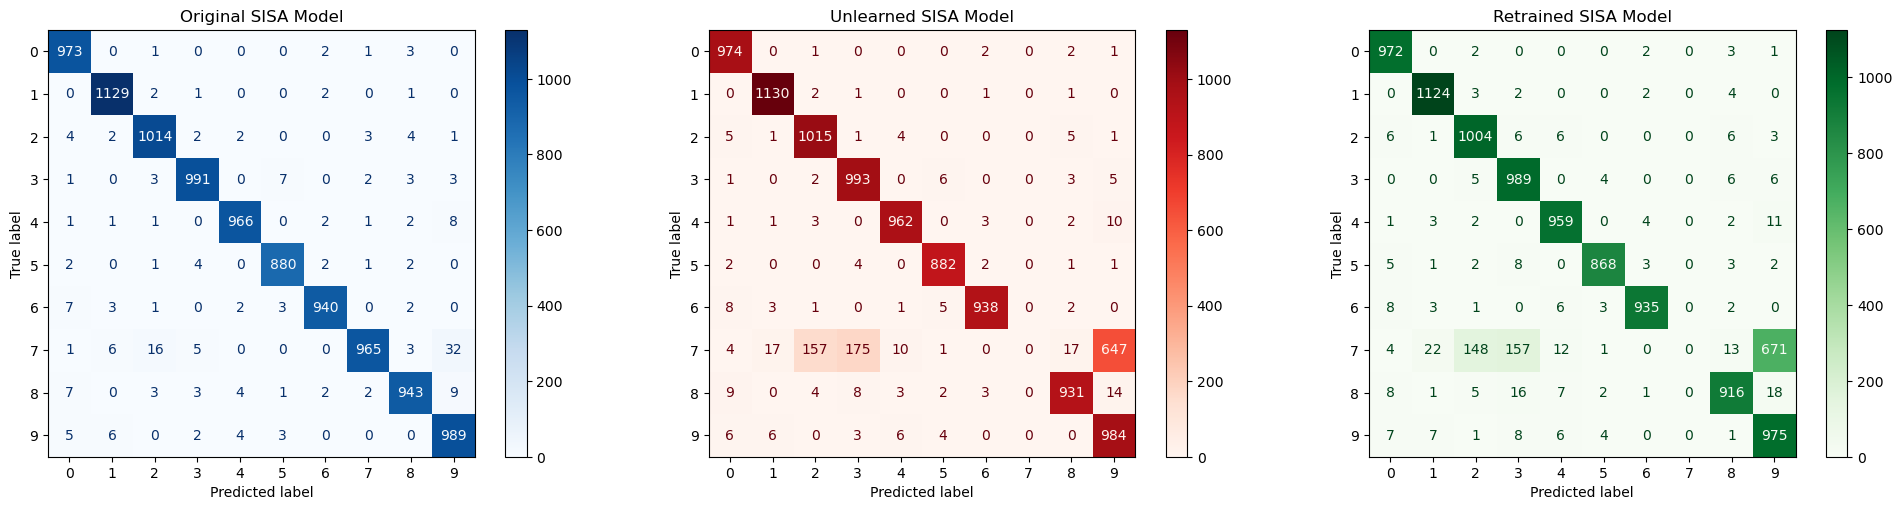

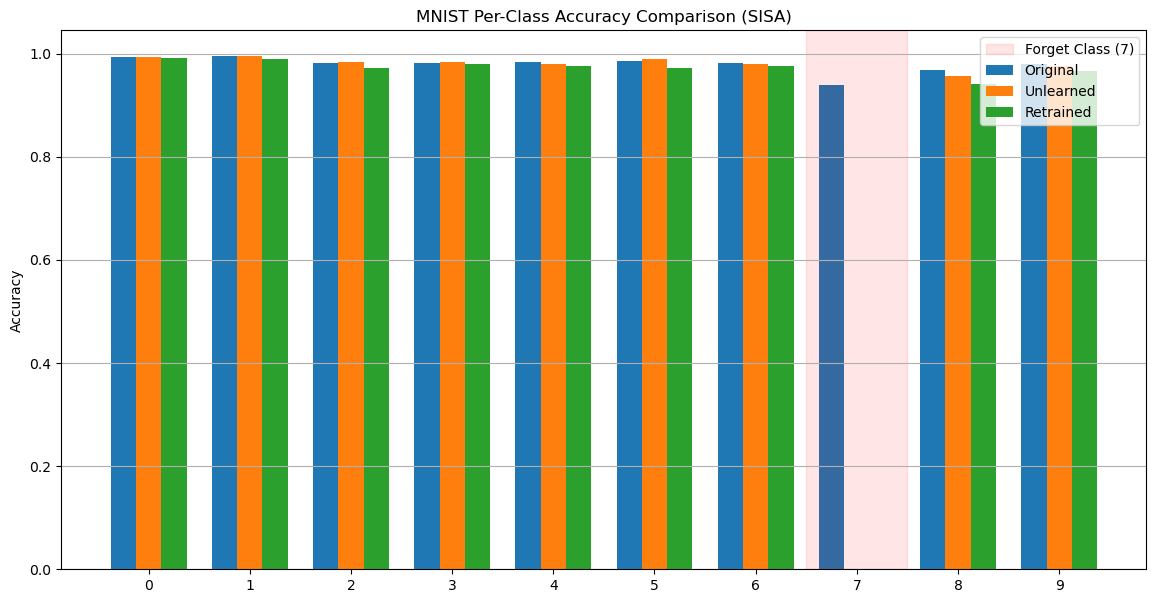

In [21]:
print("Starting MNIST SISA Experiment")

# Data preparation
transform_mnist = transforms.ToTensor()
mnist_train = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform_mnist)
mnist_test = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform_mnist)
test_loader_mnist = DataLoader(mnist_test, batch_size=128, shuffle=False)

# Split forget class (7) and retain classes
targets = mnist_train.targets.numpy()
forget_class = 7
indices_forget = np.where(targets == forget_class)[0]
indices_retain = np.where(targets != forget_class)[0]

# Create shards (10 shards total)
n_shards = 10
random.shuffle(indices_retain)
shard_size = len(indices_retain) // n_shards
shards = [indices_retain[i*shard_size:(i+1)*shard_size] for i in range(n_shards)]

# Distribute forget class equally to first k shards (k=5)
k = 5
np.random.shuffle(indices_forget)
split_forget = np.array_split(indices_forget, k)
shards_with_forget = copy.deepcopy(shards)
for i in range(k):
    shards_with_forget[i] = np.concatenate((shards_with_forget[i], split_forget[i]))

for i in range(k):
    print(f"Shard {i}: Forget class samples = {torch.sum(mnist_train.targets[shards_with_forget[i]] == forget_class).item()}")

# Train Original SISA model
print("1. Training Original SISA model...")
start_time = time.time()
original_sisa_models = []
for i in range(n_shards):
    model = SimpleCNN()
    shard_dataset = Subset(mnist_train, shards_with_forget[i])
    shard_loader = DataLoader(shard_dataset, batch_size=64, shuffle=True)
    if i < k:
        train_model(model, shard_loader, epochs=10)
    else:
        train_model(model, shard_loader, epochs=3)
    original_sisa_models.append(model)
time_original_sisa = time.time() - start_time
y_true_mnist, y_pred_original_sisa = aggregate_predictions(original_sisa_models, test_loader_mnist)
print(f"Original SISA Training Time: {time_original_sisa:.2f} seconds")

# Perform SISA Unlearning
print("2. Performing SISA Unlearning...")
start_time = time.time()
unlearned_sisa_models = copy.deepcopy(original_sisa_models)
for i in range(k):
    cleaned_indices = [idx for idx in shards_with_forget[i] if mnist_train.targets[idx] != forget_class]
    model_unlearned = SimpleCNN()
    shard_dataset = Subset(mnist_train, cleaned_indices)
    shard_loader = DataLoader(shard_dataset, batch_size=64, shuffle=True)
    train_model(model_unlearned, shard_loader, epochs=10)
    unlearned_sisa_models[i] = model_unlearned
time_unlearn_sisa = time.time() - start_time
y_true_mnist, y_pred_unlearn_sisa = aggregate_predictions(unlearned_sisa_models, test_loader_mnist)
print(f"SISA Unlearning Time: {time_unlearn_sisa:.2f} seconds")

# Train Retrained SISA model from scratch
print("3. Training Retrained SISA model from scratch...")
start_time = time.time()
retrained_sisa_models = []
for i in range(n_shards):
    model = SimpleCNN()
    shard_dataset = Subset(mnist_train, shards[i])  # Only retain data
    shard_loader = DataLoader(shard_dataset, batch_size=64, shuffle=True)
    train_model(model, shard_loader, epochs=3)
    retrained_sisa_models.append(model)
time_retrain_sisa = time.time() - start_time
y_true_mnist, y_pred_retrain_sisa = aggregate_predictions(retrained_sisa_models, test_loader_mnist)
print(f"SISA Retraining from Scratch Time: {time_retrain_sisa:.2f} seconds")

# Plot results
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_true_mnist, y_pred_original_sisa)).plot(ax=axes[0], cmap="Blues")
axes[0].set_title("Original SISA Model")
ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_true_mnist, y_pred_unlearn_sisa)).plot(ax=axes[1], cmap="Reds")
axes[1].set_title("Unlearned SISA Model")
ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_true_mnist, y_pred_retrain_sisa)).plot(ax=axes[2], cmap="Greens")
axes[2].set_title("Retrained SISA Model")
plt.tight_layout()
plt.show()

# Per-class accuracy
acc_original = per_class_accuracy(y_true_mnist, y_pred_original_sisa)
acc_unlearned = per_class_accuracy(y_true_mnist, y_pred_unlearn_sisa)
acc_retrained = per_class_accuracy(y_true_mnist, y_pred_retrain_sisa)

class_names_mnist = [str(i) for i in range(10)]
x = np.arange(len(class_names_mnist))
width = 0.25
fig, ax = plt.subplots(figsize=(14, 7))
ax.bar(x - width, acc_original, width, label='Original')
ax.bar(x, acc_unlearned, width, label='Unlearned')
ax.bar(x + width, acc_retrained, width, label='Retrained')
ax.set_ylabel('Accuracy')
ax.set_title('MNIST Per-Class Accuracy Comparison (SISA)')
ax.set_xticks(x)
ax.set_xticklabels(class_names_mnist)
ax.axvspan(forget_class - 0.5, forget_class + 0.5, color='red', alpha=0.1, label=f'Forget Class ({forget_class})')
ax.legend()
plt.grid(True, axis='y')
plt.show()



--- Starting CIFAR-10 Fine-tuning Experiment ---
1. Training Original Full model on CIFAR-10...
Epoch 1/10, Training Accuracy: 0.4297
Epoch 2/10, Training Accuracy: 0.5587
Epoch 3/10, Training Accuracy: 0.6188
Epoch 4/10, Training Accuracy: 0.6504
Epoch 5/10, Training Accuracy: 0.6747
Epoch 6/10, Training Accuracy: 0.6912
Epoch 7/10, Training Accuracy: 0.7074
Epoch 8/10, Training Accuracy: 0.7206
Epoch 9/10, Training Accuracy: 0.7287
Epoch 10/10, Training Accuracy: 0.7409
Full CIFAR-10 Training Time: 456.30 seconds
2. Performing Fine-tuning Unlearning on CIFAR-10...
Epoch 1/5, Training Accuracy: 0.7565
Epoch 2/5, Training Accuracy: 0.7648
Epoch 3/5, Training Accuracy: 0.7675
Epoch 4/5, Training Accuracy: 0.7781
Epoch 5/5, Training Accuracy: 0.7824
Fine-tuning (Unlearning) Time: 205.41 seconds
3. Training Retrained model from scratch on CIFAR-10...
Epoch 1/10, Training Accuracy: 0.4344
Epoch 2/10, Training Accuracy: 0.5489
Epoch 3/10, Training Accuracy: 0.6069
Epoch 4/10, Training Accu

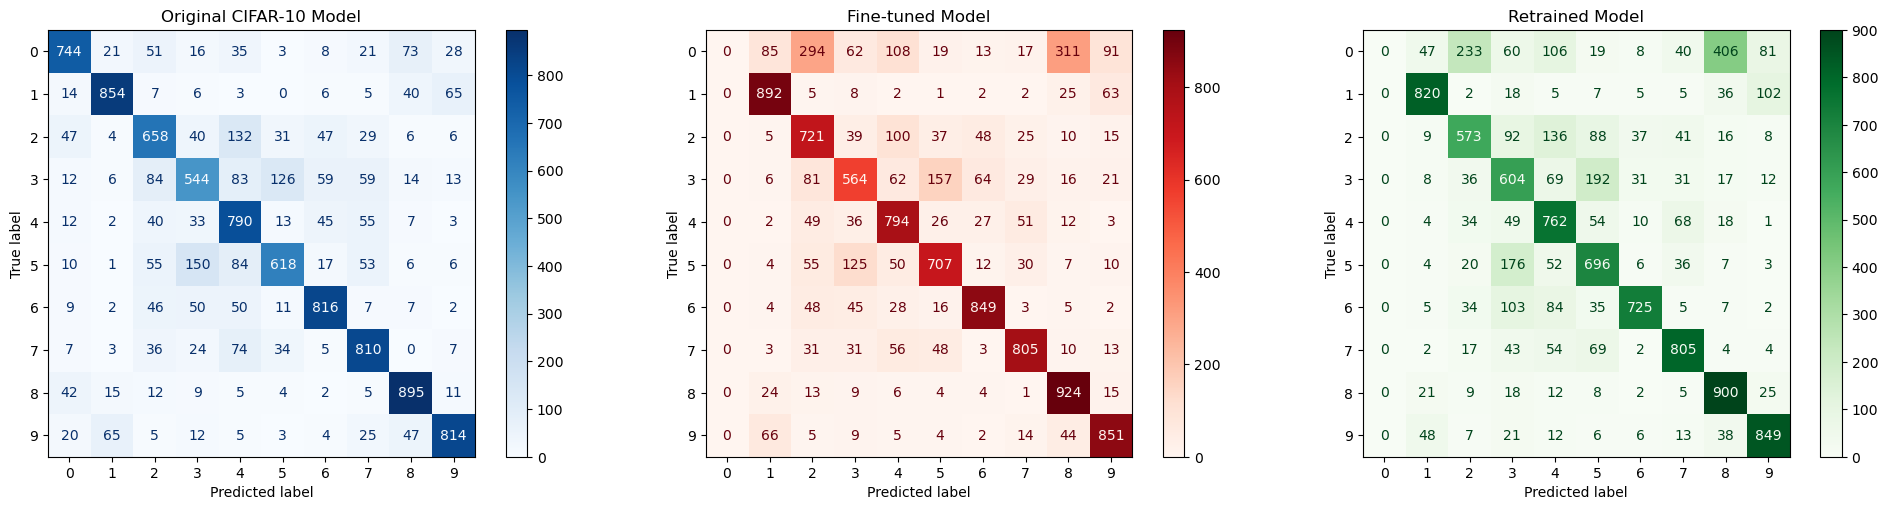

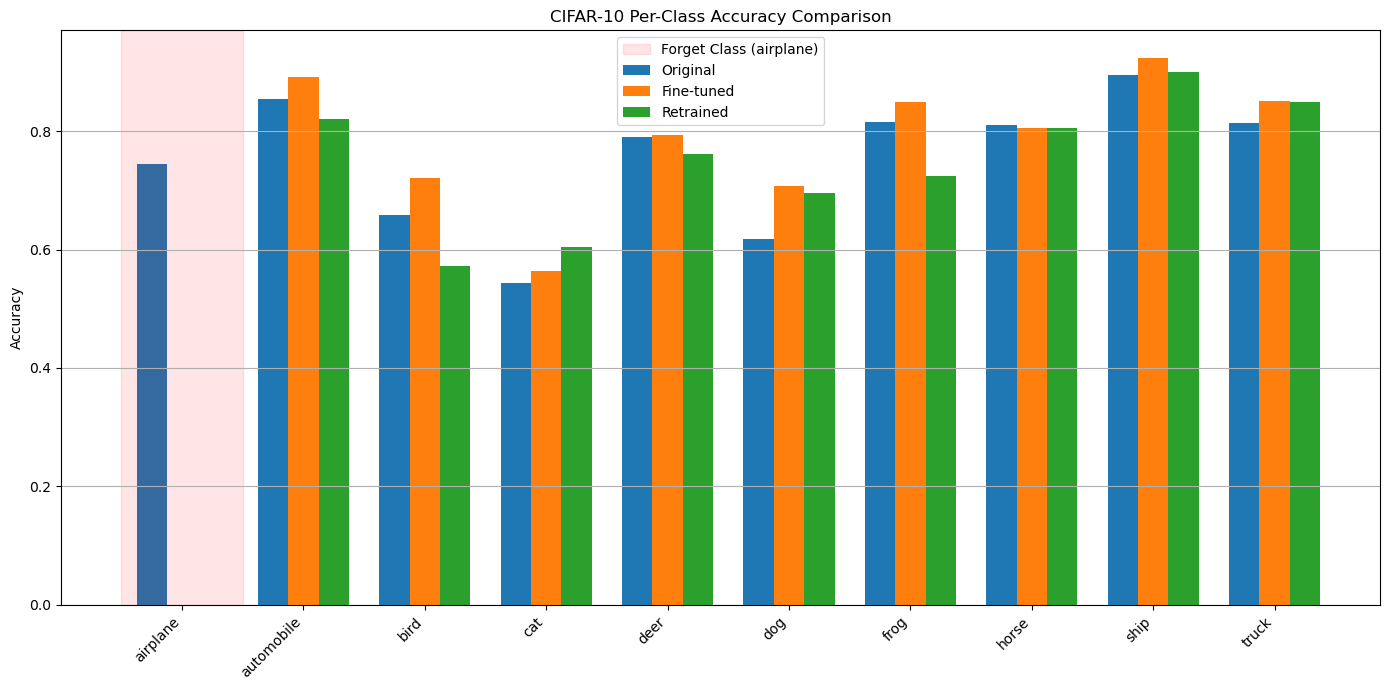

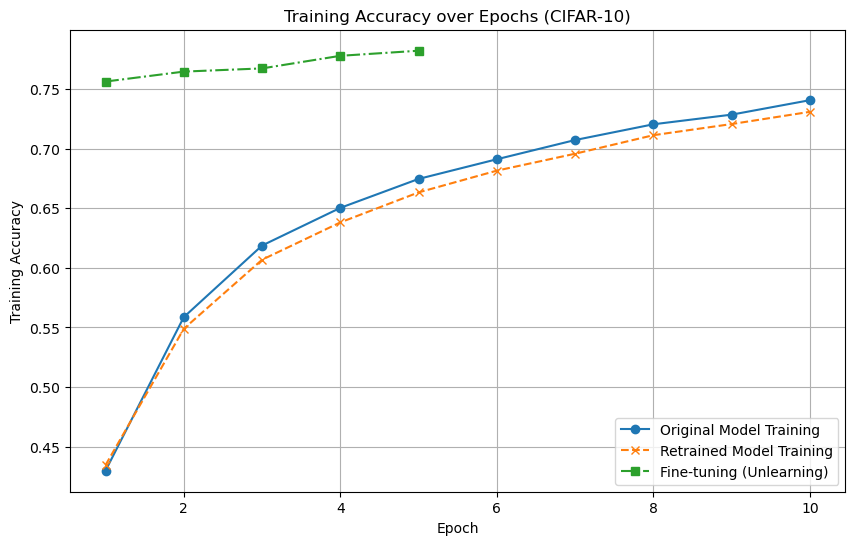

In [ ]:
print("\nStarting CIFAR-10 Fine-tuning Experiment")
# Define transformations for data augmentation during training
transform_cifar_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])
# Define transformation for test set (no augmentation)
transform_cifar_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])
# Load CIFAR-10 dataset
cifar_train = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_cifar_train)
cifar_test = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_cifar_test)
# Test data loader
test_loader_cifar = DataLoader(cifar_test, batch_size=128)
# Extract class labels for filtering
targets_cifar = np.array(cifar_train.targets)
forget_class_cifar = 0
# Create a subset excluding the forget class
indices_retain_cifar = np.where(targets_cifar != forget_class_cifar)[0]
# Data loaders
full_loader_cifar = DataLoader(cifar_train, batch_size=128, shuffle=True)
retain_loader_cifar = DataLoader(Subset(cifar_train, indices_retain_cifar), batch_size=128, shuffle=True)
# Original training
print("1. Training Original Full model on CIFAR-10...")
model_full_cifar = SmallCNN()
start_time = time.time()
model_full_cifar, acc_hist_original = train_model_with_logging(model_full_cifar, full_loader_cifar, epochs=10)
time_original_cifar = time.time() - start_time
# Evaluate on test set
y_true_cifar, y_pred_original_cifar = evaluate_model(model_full_cifar, test_loader_cifar)
print(f"Full CIFAR-10 Training Time: {time_original_cifar:.2f} seconds")
# Fine-tuning (Unlearning)
print("2. Performing Fine-tuning Unlearning on CIFAR-10...")
model_finetune_cifar = copy.deepcopy(model_full_cifar)
start_time = time.time()
model_finetune_cifar, acc_hist_finetune = train_model_with_logging(model_finetune_cifar, retain_loader_cifar, epochs=5)
time_unlearn_cifar = time.time() - start_time
# Evaluate fine-tuned model
y_true_cifar, y_pred_finetune_cifar = evaluate_model(model_finetune_cifar, test_loader_cifar)
print(f"Fine-tuning (Unlearning) Time: {time_unlearn_cifar:.2f} seconds")
# Retraining from scratch
print("3. Training Retrained model from scratch on CIFAR-10...")
model_retrained_cifar = SmallCNN()
start_time = time.time()
model_retrained_cifar, acc_hist_retrained = train_model_with_logging(model_retrained_cifar, retain_loader_cifar, epochs=10)
time_retrain_cifar = time.time() - start_time
# Evaluate retrained model
y_true_cifar, y_pred_retrain_cifar = evaluate_model(model_retrained_cifar, test_loader_cifar)
print(f"Retraining from Scratch Time: {time_retrain_cifar:.2f} seconds")
# Plot confusion matrices for all three models
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_true_cifar, y_pred_original_cifar)).plot(ax=axes[0], cmap="Blues")
axes[0].set_title("Original CIFAR-10 Model")
ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_true_cifar, y_pred_finetune_cifar)).plot(ax=axes[1], cmap="Reds")
axes[1].set_title("Fine-tuned Model")
ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_true_cifar, y_pred_retrain_cifar)).plot(ax=axes[2], cmap="Greens")
axes[2].set_title("Retrained Model")
plt.tight_layout()
plt.show()
# Calculate per-class accuracy
acc_original_cifar = per_class_accuracy(y_true_cifar, y_pred_original_cifar)
acc_finetuned_cifar = per_class_accuracy(y_true_cifar, y_pred_finetune_cifar)
acc_retrained_cifar = per_class_accuracy(y_true_cifar, y_pred_retrain_cifar)
# Plot per-class accuracy comparison
class_names_cifar = cifar_train.classes
x = np.arange(len(class_names_cifar))
width = 0.25
fig, ax = plt.subplots(figsize=(14, 7))
ax.bar(x - width, acc_original_cifar, width, label='Original')
ax.bar(x, acc_finetuned_cifar, width, label='Fine-tuned')
ax.bar(x + width, acc_retrained_cifar, width, label='Retrained')
ax.set_ylabel('Accuracy')
ax.set_title('CIFAR-10 Per-Class Accuracy Comparison')
ax.set_xticks(x)
ax.set_xticklabels(class_names_cifar, rotation=45, ha="right")
ax.axvspan(forget_class_cifar - 0.5, forget_class_cifar + 0.5, color='red', alpha=0.1, label=f'Forget Class ({class_names_cifar[forget_class_cifar]})')
ax.legend()
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()
# Plot training accuracy history over epochs
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), acc_hist_original, label='Original Model Training', marker='o', linestyle='-')
plt.plot(range(1, 11), acc_hist_retrained, label='Retrained Model Training', marker='x', linestyle='--')
plt.plot(range(1, 6), acc_hist_finetune, label='Fine-tuning (Unlearning)', marker='s', linestyle='-.')
plt.title('Training Accuracy over Epochs (CIFAR-10)')
plt.xlabel('Epoch')
plt.ylabel('Training Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from prettytable import PrettyTable
# Create a table to summarize MNIST experiment results
mnist_table = PrettyTable()
mnist_table.field_names = ["Metric", "Original", "Unlearned", "Retrained"]
mnist_table.align["Metric"] = "l" 
# Add training time for each scenario (in seconds)
mnist_table.add_row([
    "Time (s)",
    f"{time_original_sisa:.2f}",
    f"{time_unlearn_sisa:.2f}",
    f"{time_retrain_sisa:.2f}"
])
# Add overall test accuracy for each model (as percentage)
mnist_table.add_row([
    "Overall Accuracy (%)",
    f"{accuracy_score(y_true_mnist, y_pred_original_sisa)*100:.2f}",
    f"{accuracy_score(y_true_mnist, y_pred_unlearn_sisa)*100:.2f}",
    f"{accuracy_score(y_true_mnist, y_pred_retrain_sisa)*100:.2f}"
])
# Add per-class accuracy for the forgotten class
mnist_table.add_row([
    f"Forget Class ({forget_class}) Acc (%)",
    f"{acc_original[forget_class]*100:.2f}",
    f"{acc_unlearned[forget_class]*100:.2f}",
    f"{acc_retrained[forget_class]*100:.2f}"
])

# Create a table to summarize CIFAR-10 experiment results
cifar_table = PrettyTable()
cifar_table.field_names = ["Metric", "Original", "Unlearned", "Retrained"]
cifar_table.align["Metric"] = "l" 
# Add training time for each CIFAR-10 model variant
cifar_table.add_row([
    "Time (s)",
    f"{time_original_cifar:.2f}",
    f"{time_unlearn_cifar:.2f}",
    f"{time_retrain_cifar:.2f}"
])
# Add overall test accuracy
cifar_table.add_row([
    "Overall Accuracy (%)",
    f"{accuracy_score(y_true_cifar, y_pred_original_cifar)*100:.2f}",
    f"{accuracy_score(y_true_cifar, y_pred_finetune_cifar)*100:.2f}",
    f"{accuracy_score(y_true_cifar, y_pred_retrain_cifar)*100:.2f}"
])
# Add per-class accuracy for the forgotten class
cifar_table.add_row([
    f"Forget Class ({class_names_cifar[forget_class_cifar]}) Acc (%)",
    f"{acc_original_cifar[forget_class_cifar]*100:.2f}",
    f"{acc_finetuned_cifar[forget_class_cifar]*100:.2f}",
    f"{acc_retrained_cifar[forget_class_cifar]*100:.2f}"
])

# Print summary results for both experiments
print("\n--- EXPERIMENT SUMMARY ---")

print("\n--- MNIST (SISA) ---")
print(mnist_table)

print("\n--- CIFAR-10 (Fine-tuning) ---")
print(cifar_table)


--- EXPERIMENT SUMMARY ---

--- MNIST (SISA) ---
+--------------------------+----------+-----------+-----------+
| Metric                   | Original | Unlearned | Retrained |
+--------------------------+----------+-----------+-----------+
| Time (s)                 |  187.86  |   120.36  |   76.17   |
| Overall Accuracy (%)     |  97.90   |   88.09   |   87.42   |
| Forget Class (7) Acc (%) |  93.87   |    0.00   |    0.00   |
+--------------------------+----------+-----------+-----------+

--- CIFAR-10 (Fine-tuning) ---
+---------------------------------+----------+-----------+-----------+
| Metric                          | Original | Unlearned | Retrained |
+---------------------------------+----------+-----------+-----------+
| Time (s)                        |  456.30  |   205.41  |   412.88  |
| Overall Accuracy (%)            |  75.43   |   71.07   |   67.34   |
| Forget Class (airplane) Acc (%) |  74.40   |    0.00   |    0.00   |
+---------------------------------+---------